In [37]:
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers

In [38]:
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

In [39]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [40]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),        # random left-right flip
    layers.RandomRotation(0.1), 
    layers.RandomZoom(0.1),                 # zoom in/out
    layers.RandomTranslation(0.1, 0.1),     # shift image
])

In [41]:
inputs = keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)

x = layers.Conv2D(32, (3,3), activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, (3,3), activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)

outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.4013 - loss: 1.6580 - val_accuracy: 0.4768 - val_loss: 1.4757
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.4879 - loss: 1.4251 - val_accuracy: 0.5582 - val_loss: 1.2457
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5222 - loss: 1.3326 - val_accuracy: 0.5418 - val_loss: 1.3041
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5456 - loss: 1.2759 - val_accuracy: 0.5782 - val_loss: 1.2234
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5604 - loss: 1.2368 - val_accuracy: 0.6119 - val_loss: 1.1161
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5729 - loss: 1.2029 - val_accuracy: 0.6035 - val_loss: 1.1451
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.5824 - loss: 1.1774 - val_accuracy: 0.6154 - val_loss: 1.1117
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.5894 -

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np


img = image.load_img("myairplane.jpg", target_size=(32, 32)) 
img_array = image.img_to_array(img)
img_array = img_array / 255.0        
img_array = np.expand_dims(img_array, axis=0) #converted to dimension for cifar

In [ ]:
pred = model.predict(img_array)
pred_class = np.argmax(pred)
print("Predicted class index:", pred_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Predicted class index: 0


In [ ]:
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

print("Prediction:", class_names[pred_class])

Prediction: airplane


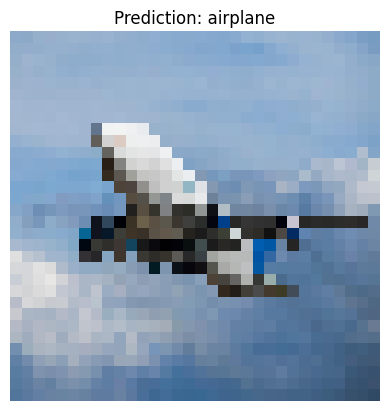

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.title("Prediction: " + class_names[np.argmax(pred)])
plt.axis("off")
plt.show()